<a href="https://colab.research.google.com/github/JeriesKawaneh/Time-Series-and-Tableau-/blob/main/TS_Belt_Exam_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.tsa.api as tsa
!pip install pmdarima
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs,nsdiffs

# Set wide fig size for plots
plt.rcParams['figure.figsize']=(12,3)

In [58]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [59]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [61]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [62]:
import statsmodels.tsa.api as tsa
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # Correct import
import matplotlib.pyplot as plt # Ensure plt is imported for subplots

def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws) # Direct call

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws) # Direct call

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

In [63]:
import pandas as pd
import numpy as np

# Load dataset
ts = pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/Time series/zillow_home_values-zipcode.csv")

# Convert date columns to long format
ts_long = ts.melt(id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName'],
                  var_name='Date',
                  value_name='Home Value')

# Convert Date column
ts_long['Date'] = pd.to_datetime(
    ts_long['Date'],
    format='%d%m%Y'
)
# Filter Oregon
ts_or = ts_long[ts_long['StateName'] == 'OR']

# Group by month (mean)
ts = ts_or.groupby('Date')['Home Value'].mean().sort_index()

# Keep required date range
ts = ts.loc['2000-01-31':'2018-12-31']

In [64]:
print(ts.isnull().sum())

# Fill missing values-no missing values


0


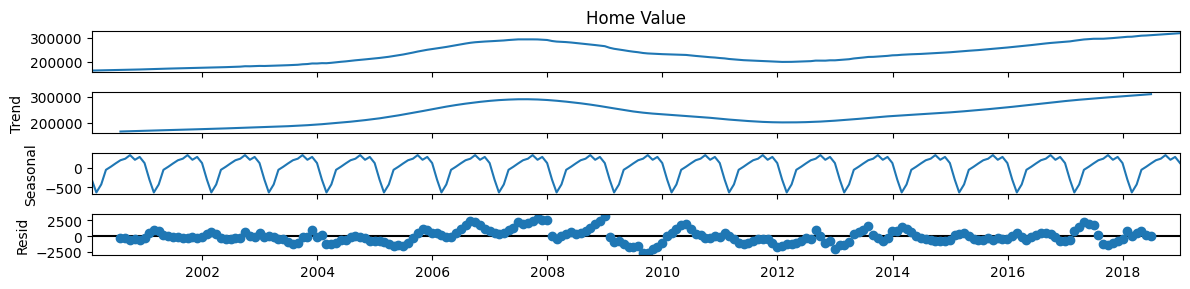

In [65]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(ts, model='additive', period=12)
decomp.plot();
# there is seasonality in the data

In [66]:
# How big is the seasonal component
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()

# How big is the seasonal component relative to the time series?
print(f"The seasonal component is {seasonal_delta: .2f} which is ~{seasonal_delta/(ts.max()-ts.min()) * 100 :.2f}% of the variation in time series.")

The seasonal component is  948.43 which is ~0.61% of the variation in time series.


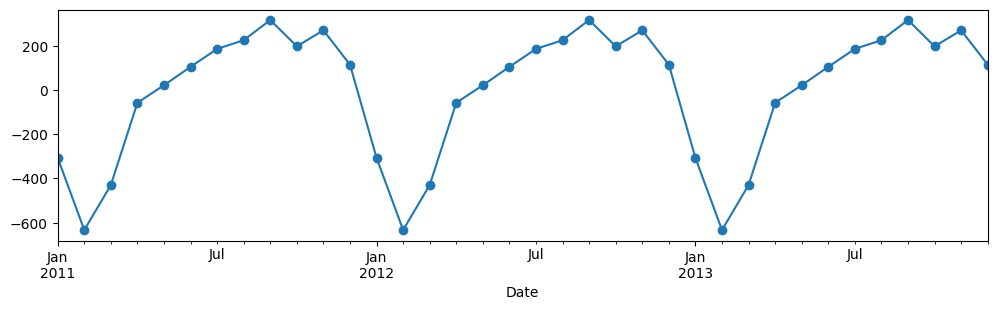

In [67]:
# Narrow down the date range of the plot
seasonal = decomp.seasonal
ax = seasonal.loc['2011': '2013'].plot(marker = 'o')

In [68]:
from statsmodels.tsa import stattools as tsa

get_adfuller_results(ts)

# the data is not stationary, The p-value of 0.387427 is greater than the significance level alpha of 0.05

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.786015,3,224,0.387427,0.05,False


In [69]:
# determine d
d = ndiffs(ts)
print (f'd = {d}')
# determine D
D = nsdiffs(ts, m = 12)
print (f'D = {D}')

d = 2
D = 0


In [70]:
ts_diff = ts.diff().diff().dropna()
get_adfuller_results(ts_diff_seasonal)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-2.93714,12,202,0.041196,0.05,True


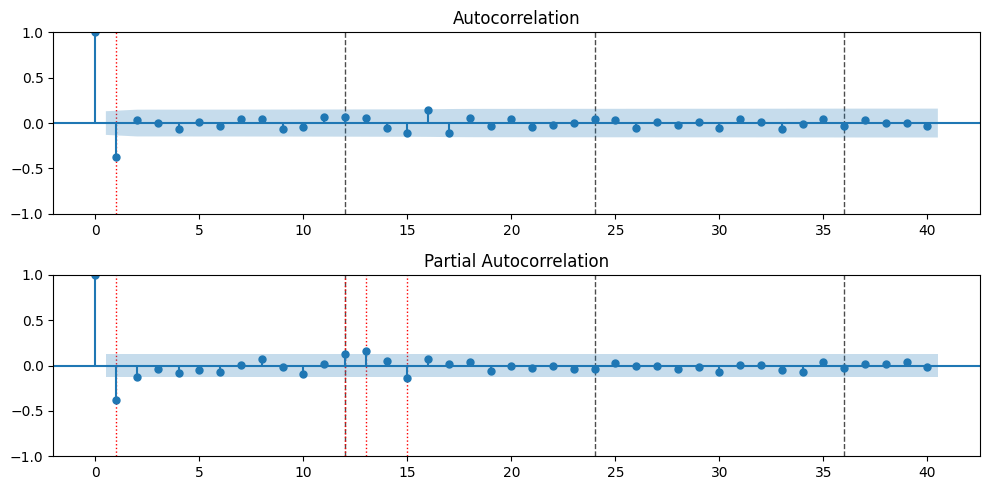

In [71]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf_pacf(ts_diff, nlags=40, annotate_sig=True, annotate_seas=True, m=12);

* Non-seasonal components (p, d, q): Both the ACF and PACF plots show a gradual decrease. This suggests potential non-seasonal AR(1) or MA(1) terms, or possibly both. Therefore, we'll start with p=1 and q=1.
Non-seasonal differencing (d): From previous analysis, we determined d=2.

* Seasonal components (P, D, Q, m): In the ACF plot, the seasonal lag at 12 shows a dramatic drop, while in the PACF plot, it gradually decreases. This suggests a seasonal MA(1) term (Q=1) and a seasonal AR(0) term (P=0).
Seasonal differencing (D, m): We previously determined D=0 with a seasonal period m=12.


Combining these observations, an educated starting point for our SARIMA model order is SARIMA(1, 2, 1)(0, 0, 1)[12]. This is an initial hypothesis, and we will explore other orders as needed.

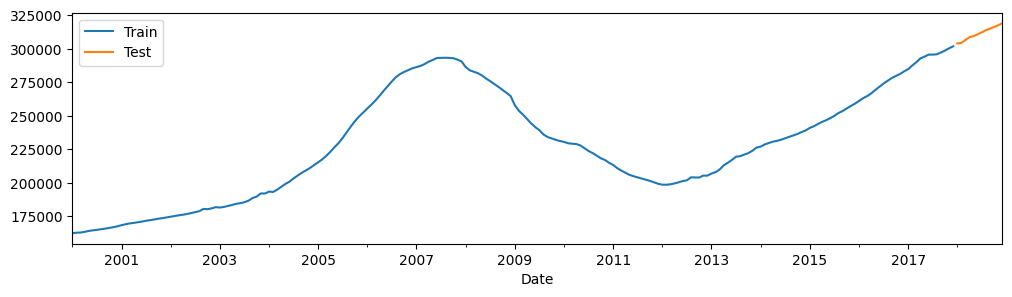

In [72]:
train, test = train_test_split(ts, test_size=12)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();

In [73]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Orders for non seasonal components
p = 1  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 1  # nonseasonal MA
# Orders for seasonal components
P = 0  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period
sarima = SARIMAX(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 379.805
- MSE = 205,455.570
- RMSE = 453.272
- R^2 = 0.991
- MAPE = 0.12%


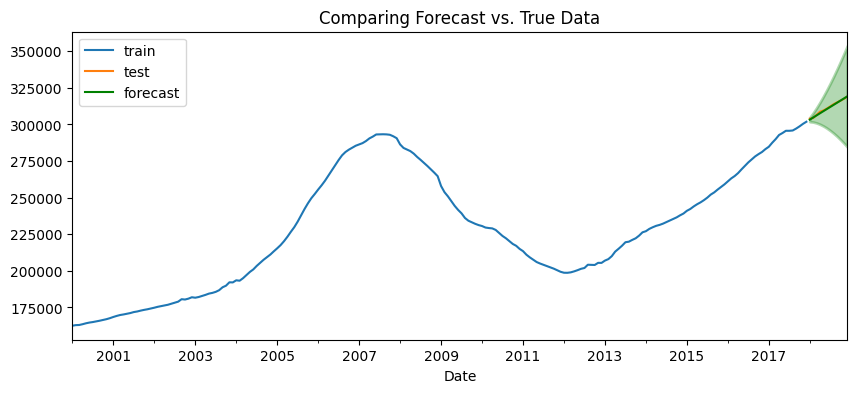

In [74]:
# Obtain summary of forecast as dataframe
forecast_df = sarima.get_forecast(len(test)).summary_frame()
# Plot the forecast with true values
plot_forecast(train, test, forecast_df)
# Obtain metrics
regression_metrics_ts(test, forecast_df["mean"])

Here's a concise explanation of the regression metrics:

*   MAE (Mean Absolute Error) = 379.805: Your forecasts are, on average, off by about $379.81 from the actual home values.

*   MSE (Mean Squared Error) = 205,455.570: This indicates the average squared error, penalizing larger deviations more heavily.

*   RMSE (Root Mean Squared Error) = 453.272: The typical forecasting error is approximately $453.27, in the same units as home values.

*   R² (R-squared) = 0.991: Your model explains 99.1% of the variance in home values, indicating an excellent fit.

*   MAPE (Mean Absolute Percentage Error) = 0.12%: Forecasts are, on average, only 0.12% away from actual values, showing very high accuracy.

Overall: These metrics demonstrate that your SARIMA model is performing exceptionally well, providing highly accurate forecasts with minimal error.

In [75]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Home Value   No. Observations:                  216
Model:             SARIMAX(1, 2, 1)x(0, 0, 1, 12)   Log Likelihood               -1725.730
Date:                            Wed, 22 Apr 2026   AIC                           3459.460
Time:                                    07:35:08   BIC                           3472.924
Sample:                                01-31-2000   HQIC                          3464.900
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5738      1.093      0.525      0.600      -1.569       2.716
ma.L1         -0.5947      1.101     -0.540      0.589      -2.753       1.563
ma.S.L12       0.0068      0.035      0.193      0.847      -0.062       0.076
sigma2      5.151e+05    2.7e+04     19.105      0.000    4.62e+05    5.68e+05
===================================================================================
Ljung-Box (L1) (Q):                  26.50   Jarque-Bera (JB):               355.84
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.30   Skew:                            -1.16
Prob(H) (two-sided):                  0.27   Kurtosis:                         8.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In ARIMA and SARIMA models, the P>|z| value indicates the statistical significance of each coefficient. If a P>|z| value is greater than 0.05 (the common significance level), it suggests that the corresponding coefficient is not statistically significant. This means that the term associated with that coefficient does not contribute substantially to the model's explanatory power and could potentially be removed.

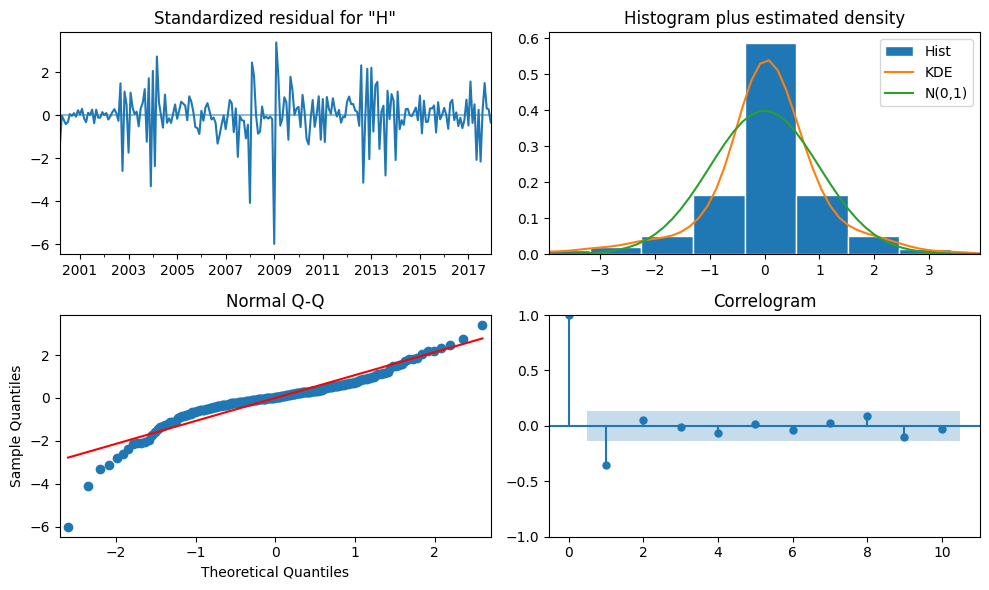

In [76]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

The current ARIMA model diagnostics reveal that the residuals are not well-behaved. Specifically:

The Normal Q-Q plot shows noticeable deviations, indicating that the residuals are not normally distributed.
The correlogram (ACF plot of residuals) contains significant autocorrelation outliers, suggesting that the model has not fully captured the time-dependent patterns in the data.
These findings imply that the present ARIMA specification may be inadequate, and further consideration should be given to alternative model orders or seasonal adjustments to improve its performance.

In [77]:
import pmdarima as pm

auto_model = pm.auto_arima(train,
                           test = 'adf',
                           seasonal=True,
                           m=12,
                           trace=True,
                           stepwise=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[12]             : AIC=3465.010, Time=4.23 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=3453.299, Time=0.12 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=3458.298, Time=0.44 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=3458.183, Time=0.59 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=3455.380, Time=0.28 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=3455.126, Time=0.44 sec
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=3458.425, Time=0.75 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=3454.641, Time=0.23 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=3456.399, Time=0.33 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=3457.674, Time=0.55 sec
 ARIMA(0,2,0)(0,0,0)[12] intercept   : AIC=3455.285, Time=0.04 sec

Best model:  ARIMA(0,2,0)(0,0,0)[12]          
Total fit time: 8.079 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:      

In [78]:
best_model = SARIMAX(train,
                     order=auto_model.order,
                     seasonal_order=auto_model.seasonal_order)

best_results = best_model.fit()
print(best_results.summary())

                               SARIMAX Results                                
Dep. Variable:             Home Value   No. Observations:                  216
Model:               SARIMAX(0, 2, 0)   Log Likelihood               -1725.649
Date:                Wed, 22 Apr 2026   AIC                           3453.299
Time:                        07:35:17   BIC                           3456.665
Sample:                    01-31-2000   HQIC                          3454.659
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.871e+05   2.82e+04     20.794      0.000    5.32e+05    6.42e+05
Ljung-Box (L1) (Q):                  28.80   Jarque-Bera (JB):               367.75
Prob(Q):                              0.00   Pr

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


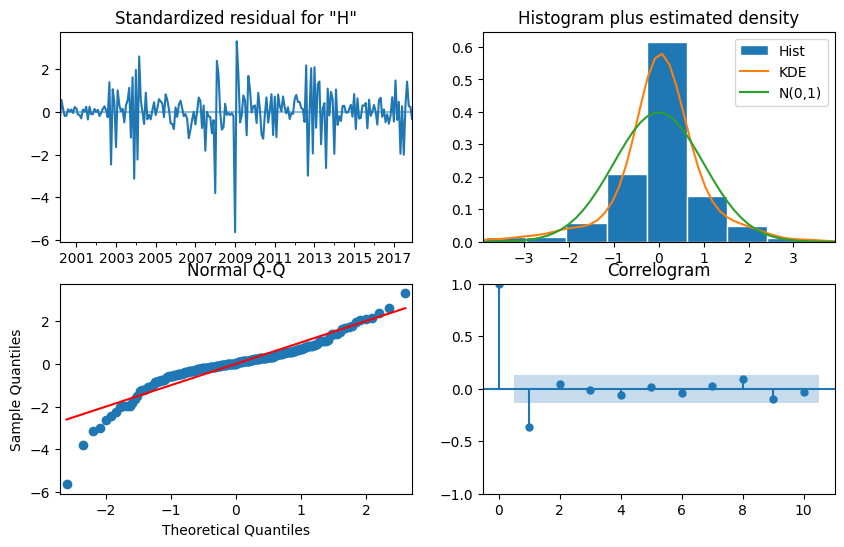

In [79]:
best_results.plot_diagnostics(figsize=(10,6));

The auto_arima model diagnostics also reveal that its residuals are not well-behaved. Specifically:

* The Normal Q-Q plot shows noticeable deviations from normality, indicating the residuals are not normally distributed.

* The correlogram (ACF plot of residuals) contains significant autocorrelation outliers, meaning the model has not fully captured the time-dependent structure.

* These findings suggest that even the auto_arima's chosen specification may be inadequate, and further consideration of alternative orders or seasonal adjustments might be necessary for a truly optimal model.

------------------------------------------------------------
Regression Metrics: Auto ARIMA
------------------------------------------------------------
- MAE = 384.272
- MSE = 204,449.052
- RMSE = 452.160
- R^2 = 0.991
- MAPE = 0.12%


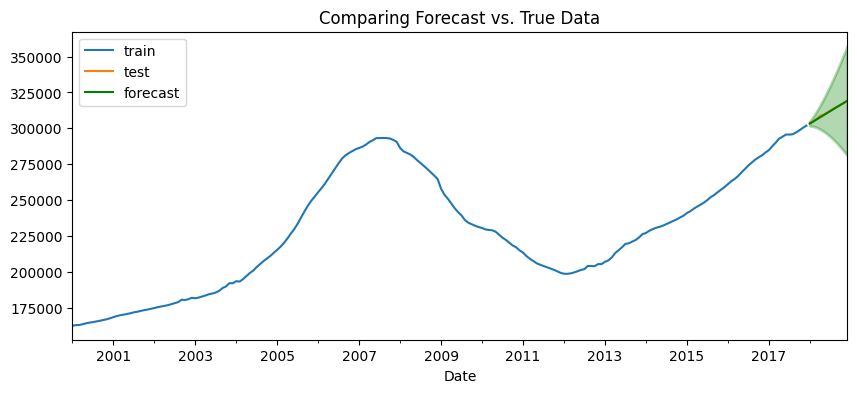

In [80]:
forecast_auto = best_results.get_forecast(steps=len(test))
forecast_auto_df = forecast_auto.summary_frame()

plot_forecast(train, test, forecast_auto_df);

regression_metrics_ts(test, forecast_auto_df['mean'], label="Auto ARIMA")

Here's a brief explanation of the Auto ARIMA regression metrics:

*   MAE = 384.272: On average, forecasts are off by about $384.27.

*   MSE = 204,449.052: Average squared error; larger errors are penalized more.

*   RMSE = 452.160: Typical forecast error is approximately $452.16.

*   R² = 0.991: The model explains 99.1% of the variance in home values.

*   MAPE = 0.12%: Forecasts are, on average, only 0.12% away from actual values, indicating very high accuracy.

Overall: The Auto ARIMA model performs exceptionally well, providing highly accurate forecasts.

In [81]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(ts,
                      order=(p,d,q),
                      seasonal_order=(P,D,Q,m))

final_results = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [82]:
future_forecast = final_results.get_forecast(steps=12)
future_df = future_forecast.summary_frame()

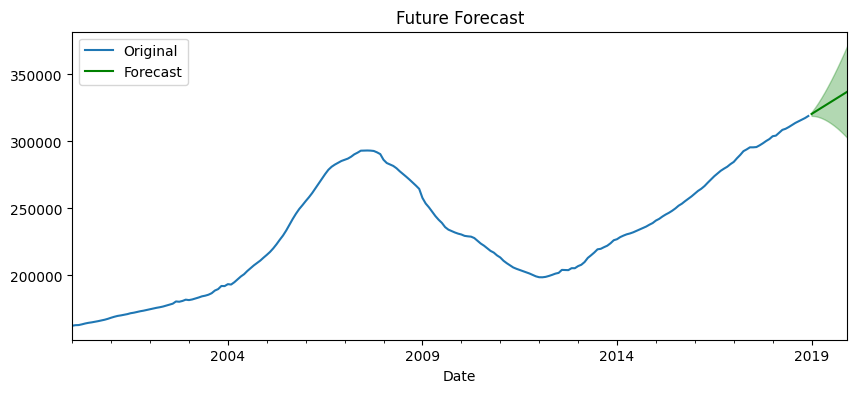

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
ts.plot(label='Original')
future_df['mean'].plot(label='Forecast', color='green')

plt.fill_between(future_df.index,
                 future_df['mean_ci_lower'],
                 future_df['mean_ci_upper'],
                 color='green', alpha=0.3)

plt.legend()
plt.title("Future Forecast");

In [84]:
final_value = future_df['mean'].iloc[-1]
percent_change = ((final_value - ts.iloc[-1]) / ts.iloc[-1]) * 100

print("Final Forecast Value:", final_value)
print("Percent Change over 12 months:", percent_change)

Final Forecast Value: 337118.84661793895
Percent Change over 12 months: 5.6717197827728665


SARIMA Forecast: The model predicts a final value of 337,118, with an estimated 5.67% increase over the next 12 months, indicating a stable and moderate upward trend in the time series.

## Final Forecast Conclusion

The model forecasts that the average home price in Oregon will reach approximately $337,118 after 12 months, representing a 5.67% increase. This suggests a stable and steadily growing housing market, with no significant signs of volatility.

# Tableau Workbook
https://public.tableau.com/app/profile/jeries.kawaneh/viz/BeltExamPart3_17768464135050/HomeValueAnalysis?publish=yes